In [2]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_tavily import TavilySearch
from langchain_core.tools import tool
import math
import requests
import os
from typing import Any

In [3]:
load_dotenv()

llm = ChatGroq(
    model="openai/gpt-oss-20b",
    api_key=os.getenv("GROQ_API_KEY")
)

In [4]:
search_tool = TavilySearch(
    max_results=5,
    topic="general",
    search_depth="advanced"
)

In [5]:
# Calculator Tool
@tool
def calculator(expression: str) -> str:
    """
    Useful for simple math calculations.
    Input should be a valid math expression.
    Example: 2 + 2, math.sqrt(16), 10 * 5
    """

    try:
        allowed = {
            "math": math,
            "abs": abs,
            "round": round,
            "min": min,
            "max": max,
            "sum": sum
        }

        result = eval(expression, {"__builtins__": {}}, allowed)
        return str(result)

    except Exception as e:
        return f"Calculation error: {str(e)}"

In [6]:
# Stock Price Tool
@tool
def get_stock_price(symbol: str) -> dict:
    """
    Fetch latest stock price for a given symbol (e.g. 'AAPL', 'TSLA') 
    using Alpha Vantage with API key in the URL.
    """
    url = f"https://www.alphavantage.co/query?function=GLOBAL_QUOTE&symbol={symbol}&apikey=os.getenv('ALPHA_API_KEY')"
    r = requests.get(url)
    return r.json()

In [7]:
# Weather Tool
@tool
def get_current_weather(location: str) -> str:
    """
    Get the current real-time weather for a given city or location.

    Args:
        location: City or location name, for example:
                  "Dhaka", "London, UK", or "New York, US".

    Returns:
        A formatted current weather report.
    """

    api_key = os.getenv("OPENWEATHER_API_KEY")

    if not api_key:
        return (
            "Weather API key is missing. "
            "Set the OPENWEATHER_API_KEY environment variable."
        )

    try:
        # Step 1: Convert the location name into latitude and longitude
        geocoding_url = "https://api.openweathermap.org/geo/1.0/direct"

        geocoding_params = {
            "q": location,
            "limit": 1,
            "appid": api_key,
        }

        geo_response = requests.get(
            geocoding_url,
            params=geocoding_params,
            timeout=10,
        )
        geo_response.raise_for_status()

        locations: list[dict[str, Any]] = geo_response.json()

        if not locations:
            return f"Could not find the location: {location}"

        latitude = locations[0]["lat"]
        longitude = locations[0]["lon"]
        resolved_name = locations[0].get("name", location)
        country = locations[0].get("country", "")
        state = locations[0].get("state", "")

        # Step 2: Get current weather using latitude and longitude
        weather_url = "https://api.openweathermap.org/data/2.5/weather"

        weather_params = {
            "lat": latitude,
            "lon": longitude,
            "appid": api_key,
            "units": "metric",
        }

        weather_response = requests.get(
            weather_url,
            params=weather_params,
            timeout=10,
        )
        weather_response.raise_for_status()

        weather_data = weather_response.json()

        temperature = weather_data["main"]["temp"]
        feels_like = weather_data["main"]["feels_like"]
        humidity = weather_data["main"]["humidity"]
        pressure = weather_data["main"]["pressure"]
        description = weather_data["weather"][0]["description"]
        wind_speed = weather_data.get("wind", {}).get("speed", "N/A")
        visibility_meters = weather_data.get("visibility")

        visibility_km = (
            round(visibility_meters / 1000, 1)
            if visibility_meters is not None
            else "N/A"
        )

        location_parts = [resolved_name]

        if state:
            location_parts.append(state)

        if country:
            location_parts.append(country)

        display_location = ", ".join(location_parts)

        return (
            f"Current weather in {display_location}:\n"
            f"- Condition: {description.title()}\n"
            f"- Temperature: {temperature}°C\n"
            f"- Feels like: {feels_like}°C\n"
            f"- Humidity: {humidity}%\n"
            f"- Pressure: {pressure} hPa\n"
            f"- Wind speed: {wind_speed} m/s\n"
            f"- Visibility: {visibility_km} km"
        )

    except requests.Timeout:
        return "The weather service request timed out. Please try again."

    except requests.HTTPError as error:
        status_code = error.response.status_code if error.response else "unknown"

        if status_code == 401:
            return "The OpenWeather API key is invalid or inactive."

        return f"Weather API returned an HTTP error: {status_code}"

    except requests.RequestException as error:
        return f"Could not connect to the weather service: {error}"

    except (KeyError, TypeError, ValueError) as error:
        return f"Unexpected weather API response: {error}"

In [8]:
tools = [search_tool, calculator, get_stock_price, get_current_weather]

In [9]:
llm_with_tools = llm.bind_tools(tools)

In [10]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]


In [12]:
def chat_node(state: ChatState):
    messages = state['messages']
    response = llm_with_tools.invoke(messages)
    return {'messages':[response]}

    tool_node = ToolNode(tools)

In [15]:
from langgraph.graph import StateGraph, START
from langgraph.prebuilt import ToolNode, tools_condition

graph = StateGraph(ChatState)

# Add nodes
graph.add_node("Chat Node", chat_node)
graph.add_node("tools", ToolNode(tools))

# Start → Chat Node
graph.add_edge(START, "Chat Node")

# Chat Node → tools OR END
graph.add_conditional_edges(
    "Chat Node",
    tools_condition
)

# tools → Chat Node
graph.add_edge("tools", "Chat Node")

# Compile graph
chatbot = graph.compile()

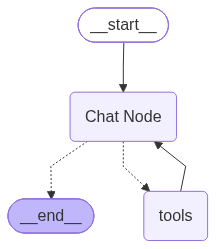

In [16]:
chatbot

In [18]:
response = chatbot.invoke({'messages':[HumanMessage(content = "Hello!")]})
print(response['messages'][-1].content)

Hi there! 👋 How can I help you today?


In [17]:
response = chatbot.invoke({'messages': [HumanMessage(content = "what is 89898 * 9099999909876 + 7342312323")]})